# 1. Validation ladder — does the pipeline measure what it claims?

**What is being measured.** DCA++ can impose the lattice point group on the Green's function `G`.
Symmetrization averages `G` over each symmetry orbit; orbit-mates are equal in expectation, so this
**reduces variance without changing the mean**. We quantify that as

$$R \;=\; \frac{\sum_x \mathrm{Var}(G[x])}{\sum_x \mathrm{Var}(\mathrm{Sym}\,G[x])}$$

read as *"symmetrization removes MC noise equivalent to ~R× more measurements, for free."*

**Why one run suffices (the paired design).** Symmetrization `P` is a *deterministic linear
operator*. So from a single set of raw per-rank samples we form **both** `Var(G)` and `Var(P·G)` —
the same noise realizations appear in numerator and denominator. The ratio is therefore *paired*,
and fluctuations largely cancel. This is dramatically tighter than comparing two independent
ON/OFF experiments, and it needs no special "no-symmetry" build of any model.

**Where the samples come from.** One MPI rank = one independent sample (DCA seeds per-rank RNG
streams by `hash(global_id + seed)`). The driver calls `local_G_k_w(symmetrize=false)` on every
rank *before* `finalize()` — giving a truly raw `G`, independent of whatever point group the binary
declares — and gathers the stack to rank 0.

**The ladder.** Each rung licenses the next:
1. **Self-consistency** — singletons pinned at exactly 1; `r` matches `m/[1+(m−1)ρ]`; `r` flat in ω.
2. **Mean preservation** — our numpy symmetrization of the raw ensemble mean must reproduce
   production's finalized `G_k_w` to machine precision.

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from symm_variance_lib import Run, predicted_r, full_symmetrize

plt.rcParams['figure.dpi'] = 110

sq = Run('../runs/square_16rank.hdf5')
fe = Run('../runs/fe_as_16rank.hdf5')

for r in (sq, fe):
    print(f"{r.model:10s} ranks={r.n_ranks:3d}  live point-group ops={r.n_ops}  "
          f"nb={r.nb} nk={r.nk} nw={r.nw}  flat entries E={r.E}")

square_D4  ranks= 16  live point-group ops=8  nb=1 nk=16 nw=256  flat entries E=16
fe_as      ranks= 16  live point-group ops=8  nb=2 nk=16 nw=128  flat entries E=64


## The orbit structure

Orbits and their per-member signs are read from the **authoritative operator `P`** serialized by the
driver (built by replaying DCA's own derive-path symmetrization formula against the
`cluster_symmetry` records). We never infer orbits by looking for equal `G` values — orbit-mates can
carry a relative **sign**, and value-matching silently splits one signed orbit into two ± classes,
corrupting orbit sizes and manufacturing a spurious `ρ=1`.

Note `m ≤ |G|`, with equality only for *free* orbits. On a 4×4 mesh every k-point lies on a mirror
line, so square tops out at `m=4` despite `|G|=8`. FeAs reaches `m=8` on the same mesh because its
group acts on the combined `(b0,b1,k)` index — a stabilizing operation can still permute bands.

In [2]:
for run in (sq, fe):
    orbs = run.orbits()
    sizes = [len(o['members']) for o in orbs if not o['forced_null']]
    nulls = sum(o['forced_null'] for o in orbs)
    from collections import Counter
    print(f"{run.model:10s} {len(orbs):3d} orbits   size histogram {dict(sorted(Counter(sizes).items()))}"
          f"   symmetry-forced nulls: {nulls}")

square_D4    6 orbits   size histogram {1: 2, 2: 1, 4: 3}   symmetry-forced nulls: 0
fe_as       34 orbits   size histogram {2: 4, 4: 4, 8: 2}   symmetry-forced nulls: 24


## Rung 1a — the built-in null control

Singleton orbits (`m=1`) are ones where `P` acts as the **identity**. They must return `r = 1`
*exactly* — not "within error". Any deviation means the pipeline is wrong. This control is free and
requires no external oracle.

In [3]:
for run in (sq, fe):
    vr = run.variance_ratios()
    var_raw, var_sym = vr['var_raw'], vr['var_sym']
    worst = 0.0
    for o in run.orbits():
        if o['forced_null'] or len(o['members']) != 1:
            continue
        x = o['members'][0]
        worst = max(worst, np.nanmax(np.abs(var_raw.real[:, :, x] / var_sym.real[:, :, x] - 1.0)))
    print(f"{run.model:10s} max |r - 1| over singleton orbits = {worst:.3e}   "
          f"{'PASS' if worst < 1e-9 else 'FAIL'}")

square_D4  max |r - 1| over singleton orbits = 0.000e+00   PASS
fe_as      max |r - 1| over singleton orbits = 0.000e+00   PASS


## Rung 1b — per-orbit `r` against `m/[1+(m−1)ρ]`

For an orbit of `m` mates with per-sample variance `σ²` and mean pairwise noise correlation `ρ`, the
symmetrized entry is a mean of `m` correlated samples:

$$\mathrm{Var}(\mathrm{Sym}\,G) = \frac{\sigma^2}{m}\big[1+(m-1)\rho\big]
\;\;\Rightarrow\;\; r = \frac{m}{1+(m-1)\rho}.$$

> **Honest caveat.** For an orbit with equal-variance mates and homogeneous pairwise correlation this
> is an *algebraic identity* on the sample moments, and we measure `ρ` from the very same samples. So
> agreement here is a strong check that orbits are genuinely exchangeable and that membership and
> **signs** are right (wrong signs break it badly) — a **pipeline** check, not independent evidence of
> the physics. The genuinely independent test is Rung 2 below.

Note `ρ` is bounded by the *symmetry-mate* correlation, not the generic one — see notebook 02.

In [4]:
def orbit_table(run):
    vr = run.variance_ratios()
    var_raw, var_sym = vr['var_raw'], vr['var_sym']
    rows = []
    for o in sorted(run.orbits(), key=lambda z: len(z['members'])):
        if o['forced_null'] or len(o['members']) < 2:
            continue
        m = len(o['members'])
        rho = run.orbit_rho(o['members'], o['signs'])
        xs = o['members']
        num = var_raw.real[:, :, xs].mean() + var_raw.imag[:, :, xs].mean()
        den = var_sym.real[:, :, xs].mean() + var_sym.imag[:, :, xs].mean()
        rows.append((m, rho, predicted_r(m, rho), num / den))
    return rows

tables = {}
for run in (sq, fe):
    tables[run.model] = orbit_table(run)
    print(f"\n{run.model}")
    print(f"  {'m':>3} {'rho':>8} {'r_pred':>8} {'r_meas':>8} {'ratio':>7}")
    for m, rho, rp, rm in tables[run.model]:
        print(f"  {m:>3} {rho:>8.4f} {rp:>8.3f} {rm:>8.3f} {rm/rp:>7.3f}")


square_D4
    m      rho   r_pred   r_meas   ratio
    2   0.8792    1.064    1.064   1.000
    4   0.9600    1.031    1.031   1.000
    4   0.9635    1.028    1.029   1.001
    4   0.9600    1.031    1.031   1.000

fe_as
    m      rho   r_pred   r_meas   ratio
    2  -0.0866    2.190    2.180   0.996
    2   0.1913    1.679    1.711   1.019
    2   0.0089    1.982    1.982   1.000
    2   0.0379    1.927    1.928   1.001
    4   0.2713    2.205    2.200   0.998
    4   0.0314    3.656    3.657   1.000
    4   0.0025    3.971    3.988   1.004
    4   0.0041    3.952    3.910   0.989
    8   0.0800    5.128    5.115   0.998
    8   0.1070    4.575    4.557   0.996


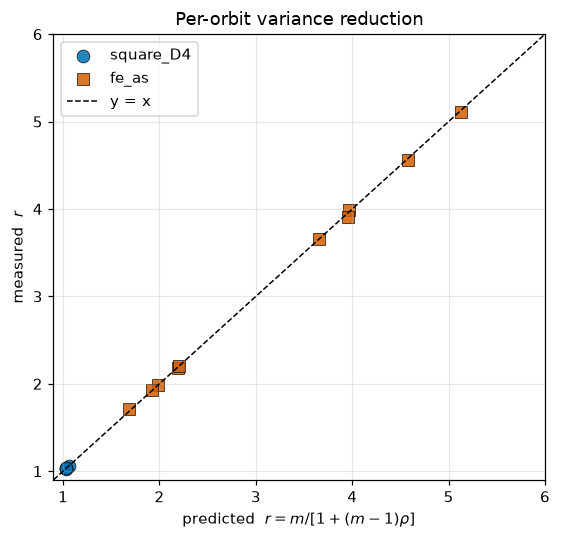

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for (name, rows), mk, col in zip(tables.items(), ('o', 's'), ('#0072B2', '#D55E00')):
    ax.scatter([r[2] for r in rows], [r[3] for r in rows], marker=mk, s=70,
               label=name, color=col, alpha=.85, edgecolor='k', linewidth=.5)
lim = [0.9, 6]
ax.plot(lim, lim, 'k--', lw=1, label='y = x')
ax.set(xlabel=r'predicted  $r = m/[1+(m-1)\rho]$', ylabel='measured  $r$',
       xlim=lim, ylim=lim, title='Per-orbit variance reduction')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()

## Rung 1c — `r` must be flat in ω

The point group acts on band and momentum indices only; it **does not touch Matsubara frequency**.
So `r` must be ω-independent. A slope here would signal contamination — e.g. frequency-domain
symmetrization leaking into what we are attributing to the point group.

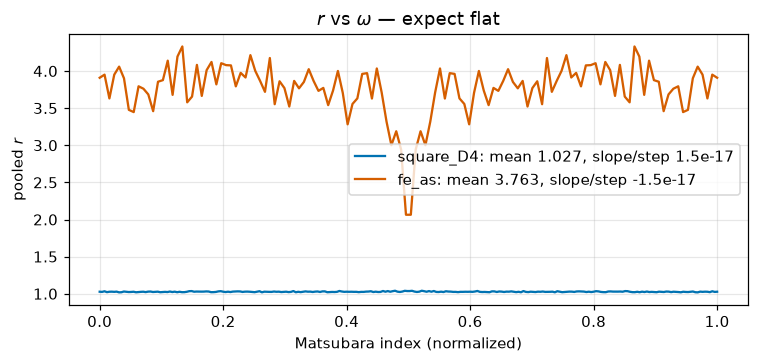

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for run, col in zip((sq, fe), ('#0072B2', '#D55E00')):
    vr = run.variance_ratios()
    var_raw, var_sym = vr['var_raw'], vr['var_sym']
    mask = np.zeros(run.E, bool)
    for o in run.orbits():
        if not o['forced_null'] and len(o['members']) > 1:
            mask[o['members']] = True
    rw = ((var_raw.real[:, :, mask].sum((1, 2)) + var_raw.imag[:, :, mask].sum((1, 2))) /
          (var_sym.real[:, :, mask].sum((1, 2)) + var_sym.imag[:, :, mask].sum((1, 2))))
    slope = np.polyfit(np.arange(run.nw), rw, 1)[0]
    ax.plot(np.linspace(0, 1, run.nw), rw, color=col,
            label=f"{run.model}: mean {rw.mean():.3f}, slope/step {slope:.1e}")
ax.set(xlabel=r'Matsubara index (normalized)', ylabel='pooled $r$', title=r'$r$ vs $\omega$ — expect flat')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()

## Headline `R`, on full and non-null support

`R` is **variance-weighted**: the noisiest entries dominate, which is the fair "total noise removed"
reading. But some entries are **symmetry-forced nulls** — the group sends them to ~0, so
`Var(Sym G) ≈ 0` and their per-entry reduction is formally infinite. The summed form tolerates them,
but they can inflate `R`, so we report both supports to make their contribution visible rather than
hidden.

In [7]:
for run in (sq, fe):
    vr = run.variance_ratios()
    var_raw, var_sym = vr['var_raw'], vr['var_sym']
    nulls = set()
    for o in run.orbits():
        if o['forced_null']:
            nulls.update(o['members'])
    nonnull = np.array([x not in nulls for x in range(run.E)])
    full = np.ones(run.E, bool)

    def R_over(mask):
        return ((var_raw.real[:, :, mask].sum() + var_raw.imag[:, :, mask].sum()) /
                (var_sym.real[:, :, mask].sum() + var_sym.imag[:, :, mask].sum()))
    print(f"{run.model:10s} R(full support) = {R_over(full):.4f}    "
          f"R(non-null support) = {R_over(nonnull):.4f}")

square_D4  R(full support) = 1.0345    R(non-null support) = 1.0345
fe_as      R(full support) = 2.4821    R(non-null support) = 2.1561


## Rung 2 — mean preservation (the independent test)

This is the rung that is *not* an identity. We take the raw per-rank samples, form the ensemble mean,
apply **our own** numpy reconstruction of the full production symmetrization, and compare against the
`G_k_w` that DCA actually finalized. Agreement to machine precision proves simultaneously that our
operator `P` matches production's `Symmetrize`, that the serialized orbit table is right, and that
symmetrization **does not move the mean**.

Two subtleties:
- `Symmetrize::execute` bundles **three** reductions — spin, point-group (cluster), and frequency
  (ω↔−ω). `full_symmetrize` reproduces all three in production order; the headline `R` above isolates
  the point-group piece.
- We use the **phase-weighted** mean `Σᵢ(signᵢ·Gᵢ)/Σᵢ(signᵢ)`, matching production's *global* sign
  normalization (`local_G_k_w` divides each rank by its *own* sign). For a sign-free model these
  coincide; they diverge once a sign problem develops.

⚠️ This rung requires `error-computation-type = NONE`. Under `JACK_KNIFE`, `finalize` writes a
*leave-one-out* replicate into `G_k_w`, which shows up as a ~3% low-frequency gap — a jackknife
artifact, not a pipeline error.

In [8]:
for run in (sq, fe):
    G_pw = full_symmetrize(run, run.phase_weighted_mean(), complex_g0=False)
    d = np.abs(G_pw - run.G_final).max()
    rel = d / np.abs(run.G_final).max()
    print(f"{run.model:10s} max|full_symmetrize(raw mean) - finalized G_k_w| = {d:.3e}  "
          f"(rel {rel:.2e})  {'PASS' if rel < 1e-8 else 'FAIL'}")

square_D4  max|full_symmetrize(raw mean) - finalized G_k_w| = 5.552e-17  (rel 2.11e-16)  PASS
fe_as      max|full_symmetrize(raw mean) - finalized G_k_w| = 2.483e-16  (rel 2.23e-16)  PASS


## Summary

All rungs pass on both models. The measured reductions are consistent with the plan's predictions:
square's single-band orbit-mates are strongly correlated (`ρ ≈ 0.9`) so the gain is modest, while
FeAs's band-mixing orbits have near-independent mates (`ρ ≈ 0`) so `r` approaches the full orbit size.

**Why the two models differ so much is the subject of notebook 02.**